In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
credit_data = pd.read_csv('C:\\Users\\USER\\Documents\\german_credit_data.csv')

In [3]:
credit_data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
credit_data.shape

(1000, 11)

In [5]:
credit_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [6]:
credit_data['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [7]:
credit_data.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [8]:
credit_data.duplicated().sum()

np.int64(0)

In [9]:
credit_data = credit_data.dropna().reset_index(drop=True)

In [10]:
credit_data

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [11]:
credit_data.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

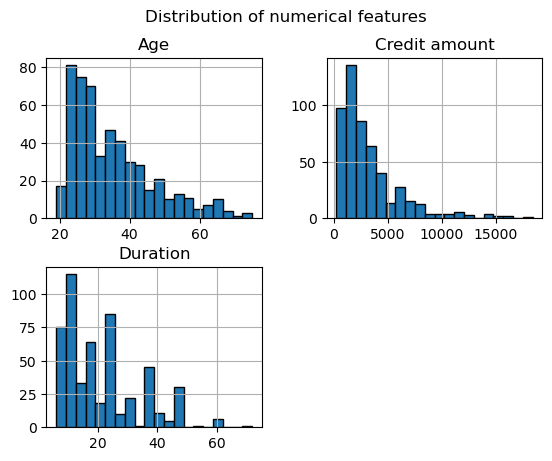

In [12]:
credit_data[["Age", "Credit amount", "Duration"]].hist(bins=20, edgecolor='black')
plt.suptitle("Distribution of numerical features")
plt.show()

In [13]:
corr = credit_data[["Age", "Credit amount", "Job", "Duration"]].corr()


In [14]:
corr

,Age,Credit amount,Job,Duration
Age,1.000000,0.082014,0.039771,0.001549
Credit amount,0.082014,1.000000,0.334721,0.613298
Job,0.039771,0.334721,1.000000,0.200794
Duration,0.001549,0.613298,0.200794,1.000000


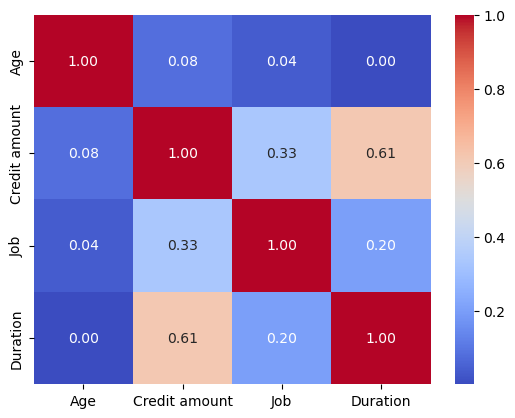

In [15]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [16]:
credit_data.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [17]:
credit_data.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [18]:
pd.pivot_table(credit_data, values= "Credit amount", index= "Housing", columns= "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


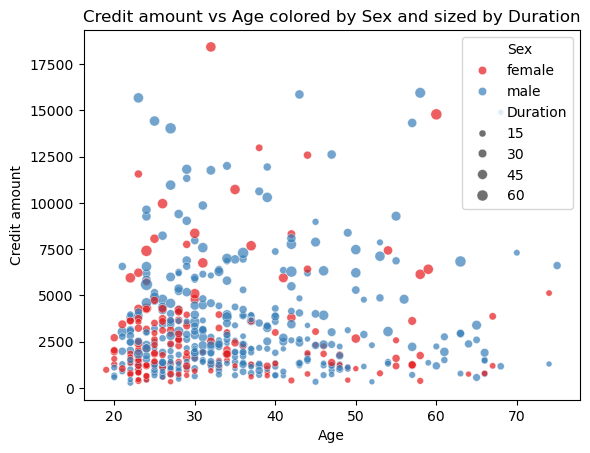

In [19]:
sns.scatterplot(credit_data, x="Age", y="Credit amount", hue= 'Sex', size = 'Duration', alpha=0.7, palette='Set1')
plt.title("Credit amount vs Age colored by Sex and sized by Duration")
plt.show()

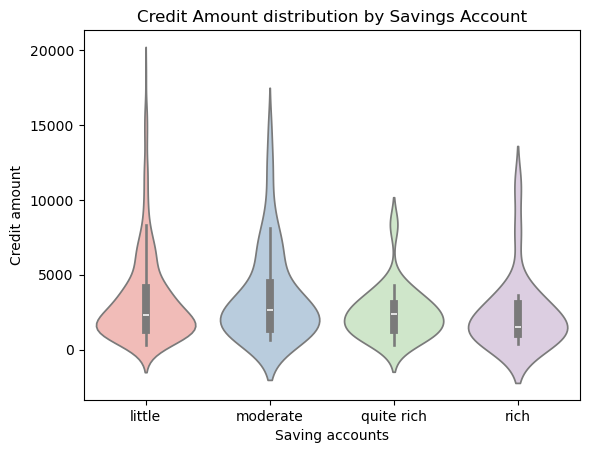

In [20]:
sns.violinplot(data=credit_data, x= 'Saving accounts', y='Credit amount', palette='Pastel1')
plt.title("Credit Amount distribution by Savings Account")
plt.show()

In [21]:
credit_data["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

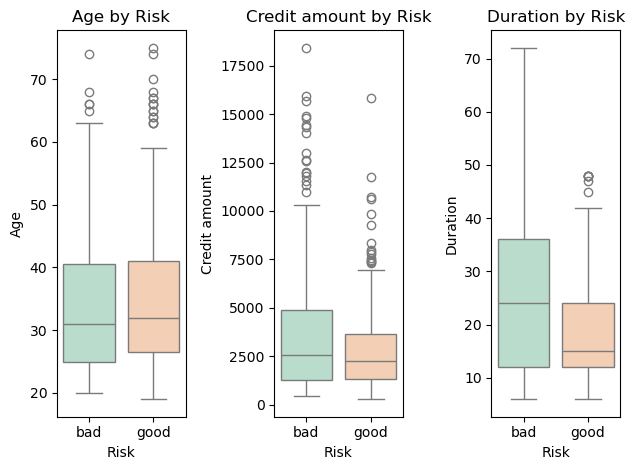

In [22]:
for i,col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1,3, i+1)
    sns.boxplot(data=credit_data, x="Risk", y=col, palette="Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [23]:
credit_data.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [24]:
categorical_cols = credit_data[["Sex", "Job", "Saving accounts", "Checking account", "Purpose"]]

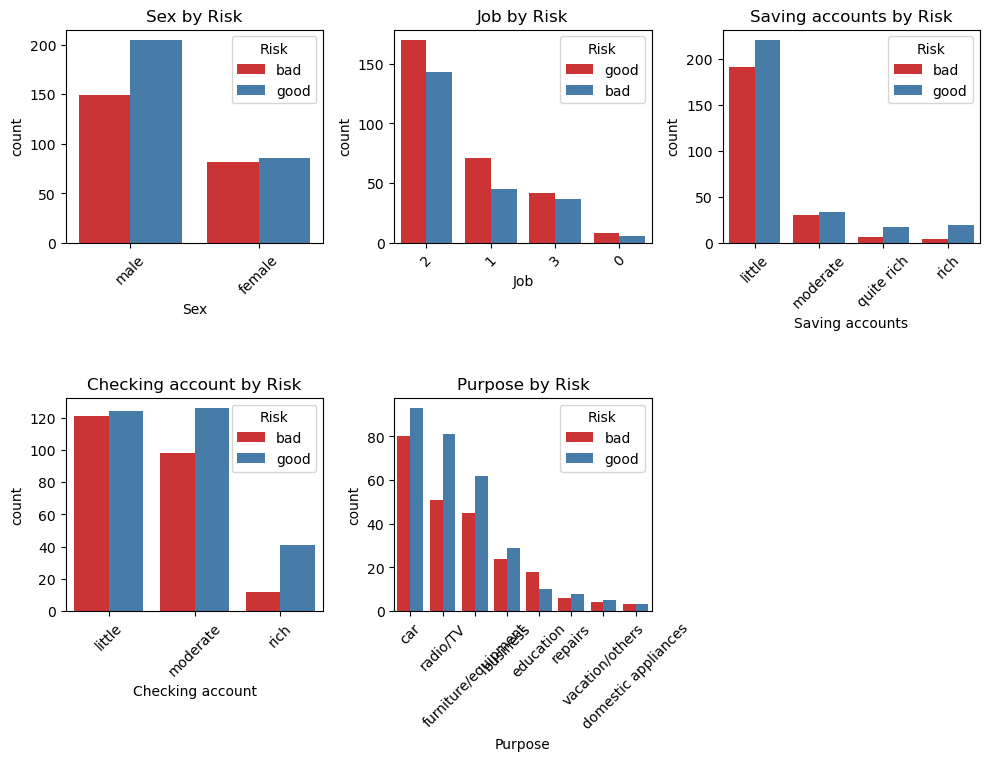

In [25]:
plt.figure(figsize = (10,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3, i+1)
    sns.countplot(data = credit_data, x= col, hue="Risk", palette = "Set1", order = credit_data[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
credit_data.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [27]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

In [28]:
target = "Risk"

In [29]:
credit_data_model = credit_data[features + [target]].copy()

In [30]:
credit_data_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [31]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [32]:
cat_cols = credit_data_model.select_dtypes(include="object").columns.drop("Risk")

In [33]:
le_dict = {}

In [34]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [35]:
for col in cat_cols:
    le = LabelEncoder()
    credit_data_model[col] = le.fit_transform(credit_data_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [36]:
le_target = LabelEncoder()

In [37]:
credit_data_model[target] = le_target.fit_transform(credit_data_model[target])

In [38]:
credit_data_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [39]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [40]:
credit_data_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X = credit_data_model.drop(target, axis=1)

In [43]:
Y = credit_data_model[target]

In [44]:
print(X)

     Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
0     22    0    2        1                0                 1           5951   
1     45    1    2        0                0                 0           7882   
2     53    1    2        0                0                 0           4870   
3     35    1    3        2                0                 1           6948   
4     28    1    3        1                0                 1           5234   
..   ...  ...  ...      ...              ...               ...            ...   
517   48    1    1        1                0                 1           1743   
518   30    1    3        1                0                 0           3959   
519   40    1    3        1                0                 0           3857   
520   23    1    2        0                0                 0           1845   
521   27    1    2        1                1                 1           4576   

     Duration  
0          

In [45]:
print(Y)

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64


In [46]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state = 1)

In [47]:
print(X.shape, X_train.shape, X_test.shape)

(522, 8) (417, 8) (105, 8)


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [49]:
def train_model(model, param_grid, X_train, Y_train, X_test, Y_test):
    grid = GridSearchCV(model, param_grid, cv = 10, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, Y_train)
    best_model = grid.best_estimator_
    Y_pred = best_model.predict(X_test)
    acc = accuracy_score(Y_test, Y_pred)
    return best_model, acc, grid.best_params_

In [50]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3,5,7,11],
    "min_samples_split": [2,4,8],
    "min_samples_leaf": [4,8,12]
}

In [51]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, Y_train, X_test, Y_test)

In [52]:
print("Decison tree accuracy", acc_dt)

Decison tree accuracy 0.5238095238095238


In [53]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 7, 'min_samples_leaf': 8, 'min_samples_split': 2}


In [54]:
rf = RandomForestClassifier(random_state = 1, class_weight = "balanced", n_jobs=-1)

In [55]:
rf_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [56]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, Y_train, X_test, Y_test)

In [57]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6571428571428571


In [58]:
print("Best Parameters", params_rf)

Best Parameters {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [59]:
et = ExtraTreesClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [60]:
et_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [61]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, Y_train, X_test, Y_test)

In [62]:
print("Extra Trees Accuracy", acc_et)

Extra Trees Accuracy 0.6666666666666666


In [63]:
print("Best paprameters", params_et)

Best paprameters {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
